# Import Packages

In [1]:
import xgi
import hypercontagion as hc
import matplotlib.pyplot as plt
import time
import numpy as np
import random
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'edge_rewiring')))
from edge_rewiring import model_generation
from edge_rewiring_exper import jaccard_similarity
#from sod.simpliciality import edit_simpliciality, face_edit_simpliciality, simplicial_fraction
from sod.trie import Trie
from sod.simpliciality.utilities import missing_subfaces, powerset

# Set Up the Hypergraph
* Specify the number of nodes
* Specify the hyperdegree distribution
* Generates a configuration model of the hypergraph

In [2]:
H = xgi.load_xgi_data("diseasome")
H.cleanup() 

In [ ]:
import uuid

og_es = xgi.edit_simpliciality(H, 2)
print(f"Original simpliciality: {og_es}")
desired_es = 0.1
# Filter edges bigger than min_size
og_edges = {frozenset(H.edges.members(edge_id)) for edge_id in H.edges}

edges = H.edges.filterby("size", 3, "geq").members()
    
# Filter maximal edges bigger than min_size
max_edges = (H.edges.maximal().filterby("size", 3, "geq").members())

# Build a trie for finding subfaces
t = Trie()
t.build_trie(edges)

# Build lists for weighted selection
set_missing_list = []
edge_remove_list = []    
   
cur_es = og_es 

print(abs((cur_es - desired_es)/desired_es))
while abs((cur_es - desired_es)/desired_es) > 0.01: 
    rewired_id_1 = str(uuid.uuid4())
    rewired_id_2 = str(uuid.uuid4())
    max_1 = random.choice(list(edges))
    max_2 = random.choice(list(edges))
    node_1 = random.choice(list(max_1))
    node_2 = random.choice(list(max_2))
    new_1 = max_1.difference({node_1}).union({node_2})
    new_2 = max_2.difference({node_2}).union({node_1})
    # Find the exact edge ID for max_1
    id_1 = next((eid for eid, nodes in H.edges.members(dtype=dict).items() if nodes == max_1), None)
    id_2 = next((eid for eid, nodes in H.edges.members(dtype=dict).items() if nodes == max_2), None)

    if id_1 is not None and id_2 is not None and id_1 != id_2:
        #print("find_max_1 and find_max_2")
        H.remove_edge(id_1)
        H.remove_edge(id_2)
        H.add_edge(new_1, idx=rewired_id_1)
        H.add_edge(new_2, idx=rewired_id_2)
        H.cleanup()
        #cur_edges = {frozenset(H.edges.members(edge_id)) for edge_id in H.edges}
        #jaccard = jaccard_similarity(cur_edges, og_edges)
        # Recalculate simpliciality
        temp_es = xgi.edit_simpliciality(H, 2)
        if abs(temp_es - desired_es) >= abs(cur_es - desired_es):
            # If the simpliciality is worse, revert the changes
            H.remove_edge(rewired_id_1)
            H.remove_edge(rewired_id_2)
            H.add_edge(max_1, idx=id_1)
            H.add_edge(max_2, idx=id_2)
        else:
            # If the simpliciality is better, keep the changes
            cur_es = temp_es
            print(f"New simpliciality: {cur_es}")
    
 
    

Original simpliciality: 0.022928994082840215
0.7707100591715978
New simpliciality: 0.022928994082840215
New simpliciality: 0.022939174189729128


KeyboardInterrupt: 

In [ ]:

print(f"Jaccard similarity: {jaccard}")

Jaccard similarity: 0.2702078521939954


# Epidemic Simulations

## Epidemic Parameters
* Initial size is the number of initial infected nodes
* $\gamma$ is the healing rate of a node
* $\mathbf{\beta}$ is the infection rate for each hyperedge size (keys are the hyperedge size and the value is the infection rate)

In [ ]:
initial_size = 100
gamma = 0.05
tau = {i: 0.1 for i in xgi.unique_edge_sizes(H)}

## Run an SIR simulation on hypergraphs
* First simulation is is with discrete time steps (DTMC)
* Second simulation is the Gillespie algorithm (CTMC)

In [ ]:
start = time.time()
t1, S1, I1, R1 = hc.discrete_SIR(H, tau, gamma, tmin=0, tmax=100, dt=1, rho=0.1)
print(time.time() - start)

start = time.time()
t2, S2, I2, R2 = hc.Gillespie_SIR(H, tau, gamma, tmin=0, tmax=100, rho=0.1)
print(time.time() - start)

start = time.time()
t3, S3, I3, R3 = hc.event_driven_SIR(H, tau, gamma, tmin=0, tmax=100, dt=1, rho=0.1)
print(time.time() - start)

0.028112173080444336
0.001415252685546875
0.0009031295776367188


### Plot the results

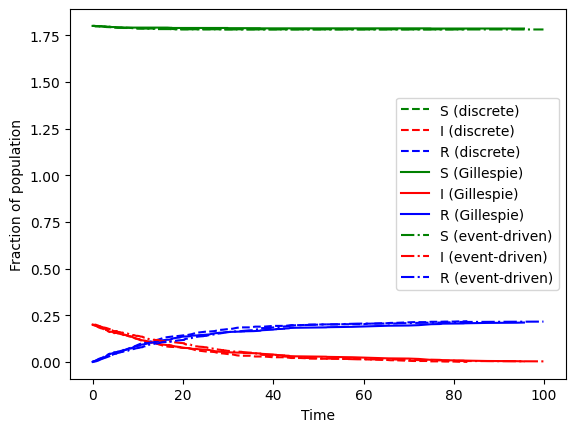

In [ ]:
plt.figure()
plt.plot(t1, S1 / n, "g--", label="S (discrete)")
plt.plot(t1, I1 / n, "r--", label="I (discrete)")
plt.plot(t1, R1 / n, "b--", label="R (discrete)")
plt.plot(t2, S2 / n, "g-", label="S (Gillespie)")
plt.plot(t2, I2 / n, "r-", label="I (Gillespie)")
plt.plot(t2, R2 / n, "b-", label="R (Gillespie)")
plt.plot(t3, S3 / n, "g-.", label="S (event-driven)")
plt.plot(t3, I3 / n, "r-.", label="I (event-driven)")
plt.plot(t3, R3 / n, "b-.", label="R (event-driven)")
plt.legend()
plt.xlabel("Time")
plt.ylabel("Fraction of population")
plt.show()

## Run an SIS simulation on hypergraphs
* First simulation is is with discrete time steps (DTMC)
* Second simulation is the Gillespie algorithm (CTMC)

In [ ]:
start = time.time()
t1, S1, I1 = hc.discrete_SIS(H, tau, gamma, tmin=0, tmax=50, dt=1, rho=0.5)
print(time.time() - start)

start = time.time()
t2, S2, I2 = hc.Gillespie_SIS(H, tau, gamma, tmin=0, tmax=50, rho=0.5)
print(time.time() - start)

start = time.time()
t3, S3, I3 = hc.event_driven_SIS(H, tau, gamma, tmin=0, tmax=50, rho=0.5)
print(time.time() - start)

0.030861854553222656
0.006764888763427734
0.006082057952880859


### Plot the results

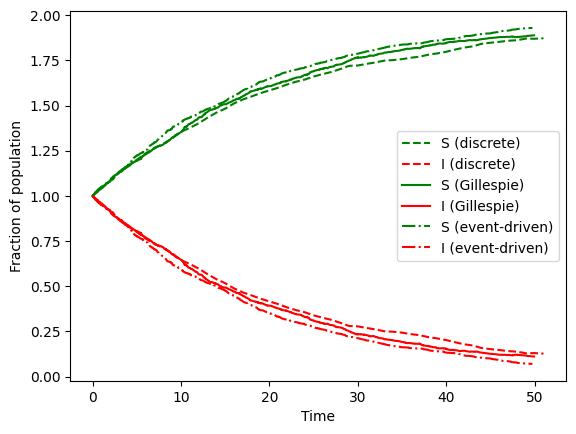

In [ ]:
plt.figure()
plt.plot(t1, S1 / n, "g--", label="S (discrete)")
plt.plot(t1, I1 / n, "r--", label="I (discrete)")
plt.plot(t2, S2 / n, "g-", label="S (Gillespie)")
plt.plot(t2, I2 / n, "r-", label="I (Gillespie)")
plt.plot(t3, S3 / n, "g-.", label="S (event-driven)")
plt.plot(t3, I3 / n, "r-.", label="I (event-driven)")
plt.legend()
plt.xlabel("Time")
plt.ylabel("Fraction of population")
plt.show()